<a href="https://colab.research.google.com/github/Git-Vivek-Gupta/Warehouse-SLA-Risk-Analytics-Automated-Alerting-System/blob/main/Python%20Notebooks%20(Colab)/warehouse_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Warehouse/zone_workload_clean.csv')

print(df.shape)
df.head()

(51203, 17)


,order_id,zone,order_date,store_id,priority_num,sku_lines,unique_skus,total_qty,unique_bins,total_weight_kg,total_volume_cm3,zone_complexity_tier,travel_seconds,pickup_seconds,base_work_seconds,base_work_minutes,simulated_work_seconds
0,BLR_120033,BISC_BAK,2025-11-14,401004.0,5,1,1,2.0,1,0.375,1805.000,4,30,10.0,40.0,0.666667,42.384228
1,BLR_120033,CHOCOLATES,2025-11-14,401004.0,5,2,2,4.0,2,0.287,1351.286,4,60,20.0,80.0,1.333333,78.672663
2,BLR_120033,DIAPERS,2025-11-14,401004.0,5,1,1,1.0,1,0.810,8615.520,3,30,5.0,35.0,0.583333,37.720292
3,BLR_120033,DP+DB,2025-11-14,401004.0,5,4,4,4.0,4,8.148,11185.250,3,120,20.0,140.0,2.333333,165.586902
4,BLR_120033,FMCG_FOOD1,2025-11-14,401004.0,5,1,1,2.0,1,0.200,2000.000,6,30,10.0,40.0,0.666667,38.876064


In [3]:
df[
    ['order_id',
     'zone',
     'priority_num',
     'total_qty',
     'unique_bins',
     'base_work_seconds']
].head(10)

,order_id,zone,priority_num,total_qty,unique_bins,base_work_seconds
0,BLR_120033,BISC_BAK,5,2.0,1,40.0
1,BLR_120033,CHOCOLATES,5,4.0,2,80.0
2,BLR_120033,DIAPERS,5,1.0,1,35.0
3,BLR_120033,DP+DB,5,4.0,4,140.0
4,BLR_120033,FMCG_FOOD1,5,2.0,1,40.0
5,BLR_120033,FMCG_FOOD2,5,6.0,4,150.0
6,BLR_120033,HNK_LARGE,5,2.0,1,40.0
7,BLR_120033,combo_11,5,8.0,6,220.0
8,BLR_120033,combo_3,5,2.0,2,70.0
9,BLR_120033,combo_4,5,12.0,12,420.0


In [4]:
queue = df.sort_values(
    by=['priority_num', 'base_work_seconds'],
    ascending=[True, False]
).reset_index(drop=True)

queue[['order_id', 'zone', 'priority_num', 'total_qty',
       'unique_bins', 'base_work_seconds']].head(20)

,order_id,zone,priority_num,total_qty,unique_bins,base_work_seconds
0,BLR_125045,combo_9,1,1562.0,375,19060.0
1,BLR_122268,combo_9,1,1799.0,296,17875.0
2,BLR_126050,combo_9,1,1432.0,355,17810.0
3,BLR_128126,combo_9,1,1310.0,366,17530.0
4,BLR_129739,combo_11,1,1230.0,364,17070.0
5,BLR_128741,combo_9,1,1217.0,349,16555.0
6,BLR_127953,combo_9,1,1423.0,304,16235.0
7,BLR_127254,combo_9,1,1276.0,320,15980.0
8,BLR_122524,combo_9,1,1298.0,302,15550.0
9,BLR_125919,combo_9,1,1254.0,309,15540.0


In [5]:
n_pickers = 45

picker_available = [0] * n_pickers

picker_available[:]

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0]

In [6]:
import numpy as np

picker_idx = np.argmin(picker_available)

task_time = queue.loc[0, 'base_work_seconds']

picker_idx, task_time

(np.int64(0), np.float64(19060.0))

In [7]:
picker_available[picker_idx] += task_time

picker_available[:5]

[np.float64(19060.0), 0, 0, 0, 0]

In [8]:
#automated
picker_available_by_day = {}
simulation = []

for date, day_group in queue.groupby('order_date'):

    # Reset all 45 pickers at the start of each day
    picker_available = [0] * 45

    # Process highest-priority work first
    day_group = day_group.sort_values('priority_num')

    for i, task in day_group.iterrows():

        picker_idx = np.argmin(picker_available)

        start_time = picker_available[picker_idx]
        end_time = start_time + task['base_work_seconds']

        simulation.append({
            'order_id': task['order_id'],
            'zone': task['zone'],
            'order_date': date,
            'priority_num': task['priority_num'],
            'total_qty': task['total_qty'],
            'base_work_seconds': task['base_work_seconds'],
            'picker_id': picker_idx + 1,
            'start_time': start_time,
            'completion_time': end_time
        })

        picker_available[picker_idx] = end_time

simulation_df = pd.DataFrame(simulation)

simulation_df.head()

,order_id,zone,order_date,priority_num,total_qty,base_work_seconds,picker_id,start_time,completion_time
0,BLR_127953,SPICES&DAL,2025-11-08,1,348.0,5280.0,1,0.0,5280.0
1,BLR_127953,combo_5,2025-11-08,1,484.0,5300.0,2,0.0,5300.0
2,BLR_127982,combo_11,2025-11-08,1,313.0,5435.0,3,0.0,5435.0
3,BLR_127954,combo_11,2025-11-08,1,196.0,5780.0,4,0.0,5780.0
4,BLR_127982,FMCG_FOOD2,2025-11-08,1,348.0,5790.0,5,0.0,5790.0


In [9]:
daily_completion = (
    simulation_df.groupby('order_date')['completion_time']
    .max()
    .div(60)
    .sort_index()
)

daily_completion

,completion_time
order_date,
2025-11-08,578.833333
2025-11-09,915.750000
2025-11-10,725.583333
2025-11-11,791.166667
2025-11-12,592.416667
2025-11-13,750.250000
2025-11-14,750.250000
2025-11-15,656.833333
2025-11-16,840.916667


In [10]:
daily_completion.describe()

,completion_time
count,31.000000
mean,772.543011
std,127.026637
min,578.833333
25%,670.416667
50%,750.250000
75%,837.833333
max,1075.166667


In [11]:
shift_max=simulation_df['completion_time'].max()
shift_hour=simulation_df['completion_time'].max() / 3600
shift_min=simulation_df['completion_time'].max() / 60
print(shift_max)
print(shift_hour)
print(shift_min)


64510.0
17.919444444444444
1075.1666666666667


In [12]:
breach_days = daily_completion[daily_completion > 900]

print("Breach days:", len(breach_days))
print("Breach rate:", len(breach_days) / len(daily_completion) * 100)
print(breach_days)

Breach days: 6
Breach rate: 19.35483870967742
order_date
2025-11-09     915.750000
2025-11-20     978.250000
2025-11-21    1032.916667
2025-12-02     909.916667
2025-12-05    1075.166667
2025-12-08     923.500000
Name: completion_time, dtype: float64


In [13]:
daily_workload = (
    simulation_df.groupby('order_date')['base_work_seconds']
    .sum()
    .div(60)
)

comparison = pd.DataFrame({
    'workload_minutes': daily_workload,
    'completion_minutes': daily_completion
})

comparison['breach'] = comparison['completion_minutes'] > 900

comparison.sort_values('workload_minutes', ascending=False)

,workload_minutes,completion_minutes,breach
order_date,,,
2025-12-05,39941.083333,1075.166667,True
2025-12-02,39759.250000,909.916667,True
2025-11-20,37203.250000,978.250000,True
2025-12-07,34792.083333,834.750000,False
2025-11-21,34392.083333,1032.916667,True
2025-12-03,33490.250000,805.583333,False
2025-12-01,33315.333333,780.750000,False
2025-11-28,32666.750000,878.000000,False
2025-11-11,32473.166667,791.166667,False


In [14]:
comparison.groupby('breach').mean(numeric_only=True)

,workload_minutes,completion_minutes
breach,,
False,29540.216667,724.533333
True,35833.111111,972.583333


In [15]:
breach_dates = breach_days.index

zone_breach_workload = (
    simulation_df[simulation_df['order_date'].isin(breach_dates)]
    .groupby('zone')
    .agg(
        total_work_minutes=('base_work_seconds', lambda x: x.sum() / 60),
        total_qty=('total_qty', 'sum'),
        order_count=('order_id', 'nunique')
    )
    .sort_values('total_work_minutes', ascending=False)
)

zone_breach_workload.head(10)

,total_work_minutes,total_qty,order_count
zone,,,
combo_9,24346.083333,100189.0,305
combo_11,17320.416667,52739.0,304
combo_6,15656.750000,47547.0,301
FMCG_FOOD2,15572.000000,60504.0,303
combo_8,12371.750000,34857.0,302
FMCG_FOOD1,12171.333333,44212.0,302
SPICES&DAL,11131.916667,40379.0,305
combo_5,10712.583333,49267.0,301
BISC_BAK,10212.166667,42410.0,305


In [16]:
zone_compare = (
    simulation_df
    .assign(
        is_breach=simulation_df['order_date'].isin(breach_dates)
    )
    .groupby(['is_breach', 'zone'])['base_work_seconds']
    .sum()
    .div(60)
    .reset_index(name='work_minutes')
)

zone_compare = zone_compare.pivot(
    index='zone',
    columns='is_breach',
    values='work_minutes'
).rename(columns={
    False: 'normal_total',
    True: 'breach_total'
})

zone_compare['normal_daily_avg'] = zone_compare['normal_total'] / 25
zone_compare['breach_daily_avg'] = zone_compare['breach_total'] / 6

zone_compare['breach_vs_normal_ratio'] = (
    zone_compare['breach_daily_avg'] /
    zone_compare['normal_daily_avg']
)

zone_compare.sort_values(
    'breach_vs_normal_ratio',
    ascending=False
).head(10)

is_breach,normal_total,breach_total,normal_daily_avg,breach_daily_avg,breach_vs_normal_ratio
zone,,,,,
combo_10,1396.250000,749.500000,55.850000,124.916667,2.236646
FRAGILE_FD,21141.500000,10186.500000,845.660000,1697.750000,2.007604
REB_G1_FD,8249.750000,3727.083333,329.990000,621.180556,1.882422
combo_5,30017.333333,10712.583333,1200.693333,1785.430556,1.487000
CICO_OIL,5238.666667,1822.916667,209.546667,303.819444,1.449889
CICO_FD,13535.833333,4579.083333,541.433333,763.180556,1.409556
LIQUID_E0,5085.083333,1702.416667,203.403333,283.736111,1.394943
FMCG_FOOD1,37197.083333,12171.333333,1487.883333,2028.555556,1.363383
CICO_D2,6568.833333,2104.000000,262.753333,350.666667,1.334585


In [17]:
zone_bottleneck = (
    simulation_df.groupby('zone')
    .agg(
        total_work_minutes=('base_work_seconds', lambda x: x.sum() / 60),
        avg_task_minutes=('base_work_seconds', lambda x: x.mean() / 60),
        max_task_minutes=('base_work_seconds', lambda x: x.max() / 60),
        task_count=('order_id', 'count')
    )
    .sort_values('max_task_minutes', ascending=False)
)

zone_bottleneck.head(10)

,total_work_minutes,avg_task_minutes,max_task_minutes,task_count
zone,,,,
combo_4,15635.250000,10.080754,605.916667,1551
combo_9,118278.166667,75.577103,317.666667,1565
combo_11,77499.000000,49.330999,284.500000,1571
FMCG_FOOD2,68323.166667,43.881289,258.250000,1557
combo_6,68887.583333,43.849512,248.083333,1571
combo_8,59161.083333,37.658233,206.583333,1571
FRAGILE_FD,31328.000000,20.263907,198.500000,1546
CICO_G2,29738.333333,21.031353,178.333333,1414
combo_5,40729.916667,26.176039,167.916667,1556


In [18]:
daily_picker_work = (
    simulation_df
    .groupby(['order_date', 'picker_id'])['base_work_seconds']
    .sum()
    .div(60)
)

daily_picker_utilization = daily_picker_work / 900 * 100

daily_picker_utilization.describe()


,base_work_seconds
count,1395.000000
mean,75.946164
std,9.906815
min,58.833333
25%,69.416667
50%,75.342593
75%,81.912037
max,119.462963


In [19]:
daily_picker_utilization.groupby('order_date').mean().sort_values(ascending=False)

,base_work_seconds
order_date,
2025-12-05,98.619959
2025-12-02,98.170988
2025-11-20,91.859877
2025-12-07,85.906379
2025-11-21,84.918724
2025-12-03,82.691975
2025-12-01,82.260082
2025-11-28,80.658642
2025-11-11,80.180658


In [20]:
order_completion = (
    simulation_df
    .groupby(['order_date', 'order_id'])
    .agg(
        order_completion_minutes=('completion_time', lambda x: x.max() / 60),
        priority_num=('priority_num', 'min'),
        total_qty=('total_qty', 'sum')
    )
    .reset_index()
)

order_completion.head(10)

,order_date,order_id,order_completion_minutes,priority_num,total_qty
0,2025-11-08,BLR_127930,544.500000,5,95.0
1,2025-11-08,BLR_127931,567.750000,5,878.0
2,2025-11-08,BLR_127932,225.750000,2,3.0
3,2025-11-08,BLR_127933,110.416667,1,446.0
4,2025-11-08,BLR_127935,110.416667,1,398.0
5,2025-11-08,BLR_127936,564.083333,5,3465.0
6,2025-11-08,BLR_127937,419.166667,3,5348.0
7,2025-11-08,BLR_127938,418.416667,3,2636.0
8,2025-11-08,BLR_127939,168.916667,1,2010.0
9,2025-11-08,BLR_127940,142.166667,1,1066.0


In [21]:
print(order_completion.shape)
print(order_completion['order_id'].nunique())

(1924, 5)
1901


In [22]:
order_completion['missed_900_min'] = (
    order_completion['order_completion_minutes'] > 900
)

order_completion['missed_900_min'].value_counts()

,count
missed_900_min,
False,1914
True,10


In [23]:
order_completion['missed_900_min'].mean() * 100

np.float64(0.5197505197505198)

In [24]:
order_completion[
    order_completion['missed_900_min']
].sort_values(
    'order_completion_minutes',
    ascending=False
).head(10)

,order_date,order_id,order_completion_minutes,priority_num,total_qty,missed_900_min
1732,2025-12-05,BLR_127797,1075.166667,5,8325.0,True
1753,2025-12-05,BLR_127819,1062.500000,5,8829.0,True
1695,2025-12-05,BLR_127759,1050.083333,5,8639.0,True
796,2025-11-21,BLR_122505,1032.916667,3,3107.0,True
738,2025-11-20,BLR_122236,978.250000,6,8485.0,True
735,2025-11-20,BLR_122233,945.416667,6,7184.0,True
1902,2025-12-08,BLR_128770,923.500000,5,8561.0,True
58,2025-11-09,BLR_128121,915.750000,5,9304.0,True
1546,2025-12-02,BLR_126847,909.916667,5,3634.0,True
1497,2025-12-02,BLR_126791,900.916667,5,5377.0,True


In [25]:
df['simulated_work_seconds'].describe()

,simulated_work_seconds
count,51203.000000
mean,1116.911408
std,1498.384164
min,18.886047
25%,197.961497
50%,562.487612
75%,1475.683097
max,46114.010021


In [26]:
df[['base_work_seconds', 'simulated_work_seconds']].head(10)

,base_work_seconds,simulated_work_seconds
0,40.0,42.384228
1,80.0,78.672663
2,35.0,37.720292
3,140.0,165.586902
4,40.0,38.876064
5,150.0,145.785535
6,40.0,47.580222
7,220.0,240.260277
8,70.0,66.056415
9,420.0,447.345026


In [27]:
simulation_df.head(10)

,order_id,zone,order_date,priority_num,total_qty,base_work_seconds,picker_id,start_time,completion_time
0,BLR_127953,SPICES&DAL,2025-11-08,1,348.0,5280.0,1,0.0,5280.0
1,BLR_127953,combo_5,2025-11-08,1,484.0,5300.0,2,0.0,5300.0
2,BLR_127982,combo_11,2025-11-08,1,313.0,5435.0,3,0.0,5435.0
3,BLR_127954,combo_11,2025-11-08,1,196.0,5780.0,4,0.0,5780.0
4,BLR_127982,FMCG_FOOD2,2025-11-08,1,348.0,5790.0,5,0.0,5790.0
5,BLR_127953,CICO_G2,2025-11-08,1,989.0,5845.0,6,0.0,5845.0
6,BLR_127982,combo_6,2025-11-08,1,375.0,5865.0,7,0.0,5865.0
7,BLR_127954,combo_6,2025-11-08,1,226.0,5960.0,8,0.0,5960.0
8,BLR_127953,FMCG_FOOD2,2025-11-08,1,380.0,6100.0,9,0.0,6100.0
9,BLR_127953,FMCG_FOOD1,2025-11-08,1,460.0,6110.0,10,0.0,6110.0


In [28]:
simulation_df_deterministic = simulation_df.copy()

# Real world scenerio:

1.   base_work_seconds       = deterministic operational model
2.   simulated_work_seconds  = stochastic simulation model




In [29]:
queue = df.sort_values(
    by=['order_date', 'priority_num'],
    ascending=[True, True]
).reset_index(drop=True)

In [30]:
simulation = []

for date, day_group in queue.groupby('order_date'):

    picker_available = [0] * 45

    day_group = day_group.sort_values('priority_num')

    for _, task in day_group.iterrows():

        picker_idx = np.argmin(picker_available)

        start_time = picker_available[picker_idx]
        end_time = start_time + task['simulated_work_seconds']

        simulation.append({
            'order_id': task['order_id'],
            'zone': task['zone'],
            'order_date': date,
            'priority_num': task['priority_num'],
            'total_qty': task['total_qty'],
            'simulated_work_seconds': task['simulated_work_seconds'],
            'picker_id': picker_idx + 1,
            'start_time': start_time,
            'completion_time': end_time
        })

        picker_available[picker_idx] = end_time

simulation_df = pd.DataFrame(simulation)

simulation_df.head()

,order_id,zone,order_date,priority_num,total_qty,simulated_work_seconds,picker_id,start_time,completion_time
0,BLR_127933,REB_G1_FD,2025-11-08,1,3.0,92.599735,1,0.0,92.599735
1,BLR_127933,H_STAPLES,2025-11-08,1,3.0,49.081114,2,0.0,49.081114
2,BLR_127933,HNK_LARGE,2025-11-08,1,4.0,53.373776,3,0.0,53.373776
3,BLR_127933,FRAGILE_FD,2025-11-08,1,33.0,506.614674,4,0.0,506.614674
4,BLR_127933,FMCG_FOOD2,2025-11-08,1,1.0,35.090124,5,0.0,35.090124


In [31]:
daily_completion = (
    simulation_df.groupby('order_date')['completion_time']
    .max()
    .div(60)
    .sort_index()
)

daily_completion.describe()

,completion_time
count,31.000000
mean,785.950462
std,147.141263
min,587.952245
25%,684.165303
50%,749.177450
75%,845.314546
max,1255.211718


In [32]:
order_completion = (
    simulation_df
    .groupby(['order_date', 'order_id'])
    .agg(
        order_completion_minutes=('completion_time', lambda x: x.max() / 60),
        priority_num=('priority_num', 'min'),
        total_qty=('total_qty', 'sum')
    )
    .reset_index()
)

print(order_completion.shape)
order_completion.head()

(1924, 5)


,order_date,order_id,order_completion_minutes,priority_num,total_qty
0,2025-11-08,BLR_127930,516.460516,5,95.0
1,2025-11-08,BLR_127931,543.186435,5,878.0
2,2025-11-08,BLR_127932,221.092753,2,3.0
3,2025-11-08,BLR_127933,138.011361,1,446.0
4,2025-11-08,BLR_127935,140.732117,1,398.0


In [33]:
order_completion['risk_percentile'] = (
    order_completion
    .groupby('order_date')['order_completion_minutes']
    .rank(pct=True)
)

In [34]:
order_completion['high_risk'] = (
    order_completion['risk_percentile'] > 0.90
)

In [35]:
order_completion['high_risk'].value_counts()

,count
high_risk,
False,1717
True,207


In [36]:
order_completion['high_risk'].mean() * 100

np.float64(10.75883575883576)

In [37]:
print("=== SIMULATION DATAFRAME ===")
print(simulation_df.shape)
print(simulation_df.columns.tolist())
display(simulation_df.head())

print("\n=== DAILY COMPLETION ===")
print(daily_completion.shape)
display(daily_completion.head())

print("\n=== ORDER COMPLETION ===")
print(order_completion.shape)
print(order_completion.columns.tolist())
display(order_completion.head())

print("\n=== RISK TARGET ===")
print(order_completion['high_risk'].value_counts())

=== SIMULATION DATAFRAME ===
(51203, 9)
['order_id', 'zone', 'order_date', 'priority_num', 'total_qty', 'simulated_work_seconds', 'picker_id', 'start_time', 'completion_time']


,order_id,zone,order_date,priority_num,total_qty,simulated_work_seconds,picker_id,start_time,completion_time
0,BLR_127933,REB_G1_FD,2025-11-08,1,3.0,92.599735,1,0.0,92.599735
1,BLR_127933,H_STAPLES,2025-11-08,1,3.0,49.081114,2,0.0,49.081114
2,BLR_127933,HNK_LARGE,2025-11-08,1,4.0,53.373776,3,0.0,53.373776
3,BLR_127933,FRAGILE_FD,2025-11-08,1,33.0,506.614674,4,0.0,506.614674
4,BLR_127933,FMCG_FOOD2,2025-11-08,1,1.0,35.090124,5,0.0,35.090124



=== DAILY COMPLETION ===
(31,)


,completion_time
order_date,
2025-11-08,587.952245
2025-11-09,800.816918
2025-11-10,712.007502
2025-11-11,821.510438
2025-11-12,601.379080



=== ORDER COMPLETION ===
(1924, 7)
['order_date', 'order_id', 'order_completion_minutes', 'priority_num', 'total_qty', 'risk_percentile', 'high_risk']


,order_date,order_id,order_completion_minutes,priority_num,total_qty,risk_percentile,high_risk
0,2025-11-08,BLR_127930,516.460516,5,95.0,0.781818,False
1,2025-11-08,BLR_127931,543.186435,5,878.0,0.836364,False
2,2025-11-08,BLR_127932,221.092753,2,3.0,0.327273,False
3,2025-11-08,BLR_127933,138.011361,1,446.0,0.127273,False
4,2025-11-08,BLR_127935,140.732117,1,398.0,0.145455,False



=== RISK TARGET ===
high_risk
False    1717
True      207
Name: count, dtype: int64


#Feature Engineering for ML model


In [38]:
df.columns.tolist()

['order_id',
 'zone',
 'order_date',
 'store_id',
 'priority_num',
 'sku_lines',
 'unique_skus',
 'total_qty',
 'unique_bins',
 'total_weight_kg',
 'total_volume_cm3',
 'zone_complexity_tier',
 'travel_seconds',
 'pickup_seconds',
 'base_work_seconds',
 'base_work_minutes',
 'simulated_work_seconds']

In [39]:
order_features = (
    df.groupby(['order_date', 'order_id'])
    .agg(
        priority_num=('priority_num', 'min'),
        sku_lines=('sku_lines', 'sum'),
        unique_skus=('unique_skus', 'sum'),
        total_qty=('total_qty', 'sum'),
        unique_bins=('unique_bins', 'sum'),
        total_weight_kg=('total_weight_kg', 'sum'),
        total_volume_cm3=('total_volume_cm3', 'sum'),
        number_of_zones=('zone', 'nunique'),
        total_travel_seconds=('travel_seconds', 'sum'),
        total_pickup_seconds=('pickup_seconds', 'sum'),
        total_base_work_seconds=('base_work_seconds', 'sum')
    )
    .reset_index()
)

In [40]:
order_features = order_features.merge(
    order_completion[
        ['order_date', 'order_id', 'high_risk']
    ],
    on=['order_date', 'order_id'],
    how='inner'
)

In [41]:
print(order_features.shape)
display(order_features.head())

(1924, 14)


,order_date,order_id,priority_num,sku_lines,unique_skus,total_qty,unique_bins,total_weight_kg,total_volume_cm3,number_of_zones,total_travel_seconds,total_pickup_seconds,total_base_work_seconds,high_risk
0,2025-11-08,BLR_127930,5,57,55,95.0,56,24.440350,140348.561568,17,1680,475.0,2155.0,False
1,2025-11-08,BLR_127931,5,292,277,878.0,287,164.997302,456486.714708,32,8610,4390.0,13000.0,False
2,2025-11-08,BLR_127932,2,1,1,3.0,1,0.001000,115.500000,1,30,15.0,45.0,False
3,2025-11-08,BLR_127933,1,144,137,446.0,143,34.275320,265176.465086,24,4290,2230.0,6520.0,False
4,2025-11-08,BLR_127935,1,195,186,398.0,186,65.945480,365160.304714,28,5580,1990.0,7570.0,False


In [42]:
print("Missing values:")
print(order_features.isna().sum())

print("\nTarget balance:")
print(order_features['high_risk'].value_counts())

Missing values:
order_date                 0
order_id                   0
priority_num               0
sku_lines                  0
unique_skus                0
total_qty                  0
unique_bins                0
total_weight_kg            0
total_volume_cm3           0
number_of_zones            0
total_travel_seconds       0
total_pickup_seconds       0
total_base_work_seconds    0
high_risk                  0
dtype: int64

Target balance:
high_risk
False    1717
True      207
Name: count, dtype: int64


In [43]:
order_features.dtypes

,0
order_date,object
order_id,object
priority_num,int64
sku_lines,int64
unique_skus,int64
total_qty,float64
unique_bins,int64
total_weight_kg,float64
total_volume_cm3,float64
number_of_zones,int64


In [44]:
order_features = order_features.drop(
    columns=['total_travel_seconds', 'total_pickup_seconds']
)

In [45]:
X = order_features.drop(
    columns=['order_date', 'order_id', 'high_risk']
)

y = order_features['high_risk']

In [46]:
print(X.shape)
print(X.columns.tolist())

(1924, 9)
['priority_num', 'sku_lines', 'unique_skus', 'total_qty', 'unique_bins', 'total_weight_kg', 'total_volume_cm3', 'number_of_zones', 'total_base_work_seconds']


In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.value_counts())
print("y_test:", y_test.value_counts())

X_train: (1539, 9)
X_test: (385, 9)
y_train: high_risk
False    1373
True      166
Name: count, dtype: int64
y_test: high_risk
False    344
True      41
Name: count, dtype: int64


In [48]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

In [49]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("Classification Report:")
print(classification_report(y_test, y_pred_log))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))

Classification Report:
              precision    recall  f1-score   support

       False       0.99      0.89      0.94       344
        True       0.51      0.95      0.66        41

    accuracy                           0.90       385
   macro avg       0.75      0.92      0.80       385
weighted avg       0.94      0.90      0.91       385

Confusion Matrix:
[[306  38]
 [  2  39]]
ROC-AUC: 0.9789421440726035


In [50]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [51]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Classification Report:
              precision    recall  f1-score   support

       False       0.94      0.98      0.96       344
        True       0.77      0.49      0.60        41

    accuracy                           0.93       385
   macro avg       0.86      0.74      0.78       385
weighted avg       0.92      0.93      0.92       385

Confusion Matrix:
[[338   6]
 [ 21  20]]
ROC-AUC: 0.9367555303460011


In [52]:
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': log_model.coef_[0]
})

coef_df['abs_coefficient'] = coef_df['coefficient'].abs()

coef_df.sort_values(
    'abs_coefficient',
    ascending=False
)

,feature,coefficient,abs_coefficient
0,priority_num,4.243847,4.243847
6,total_volume_cm3,1.693756,1.693756
5,total_weight_kg,-0.459209,0.459209
3,total_qty,0.413068,0.413068
7,number_of_zones,0.399058,0.399058
2,unique_skus,-0.343585,0.343585
1,sku_lines,0.151283,0.151283
8,total_base_work_seconds,0.110386,0.110386
4,unique_bins,-0.081638,0.081638


In [53]:
import shap

explainer = shap.LinearExplainer(
    log_model,
    X_train_scaled
)

shap_values = explainer(X_test_scaled)

shap_values

.values =
array([[-0.14872924, -0.06493012,  0.14869463, ..., -0.54438153,
         0.15216244, -0.0487795 ],
       [ 4.80891207, -0.03659037,  0.08389681, ..., -0.40662337,
         0.15216244, -0.02770289],
       [-5.10637055, -0.00825061,  0.01189924, ..., -0.33746681,
         0.21760865, -0.01019712],
       ...,
       [ 4.80891207,  0.33316323, -0.74472983, ...,  2.46887797,
         0.34850107,  0.28679145],
       [-5.10637055, -0.05664208,  0.12316822, ..., -0.5868478 ,
         0.21760865, -0.03876376],
       [ 4.80891207, -0.15583122,  0.36337831, ..., -1.74859958,
        -0.79680761, -0.11237947]])

.base_values =
array([-3.88921489, -3.88921489, -3.88921489, -3.88921489, -3.88921489,
       -3.88921489, -3.88921489, -3.88921489, -3.88921489, -3.88921489,
       -3.88921489, -3.88921489, -3.88921489, -3.88921489, -3.88921489,
       -3.88921489, -3.88921489, -3.88921489, -3.88921489, -3.88921489,
       -3.88921489, -3.88921489, -3.88921489, -3.88921489, -3.88921489,
 

In [54]:
print(shap_values.shape)

(385, 9)


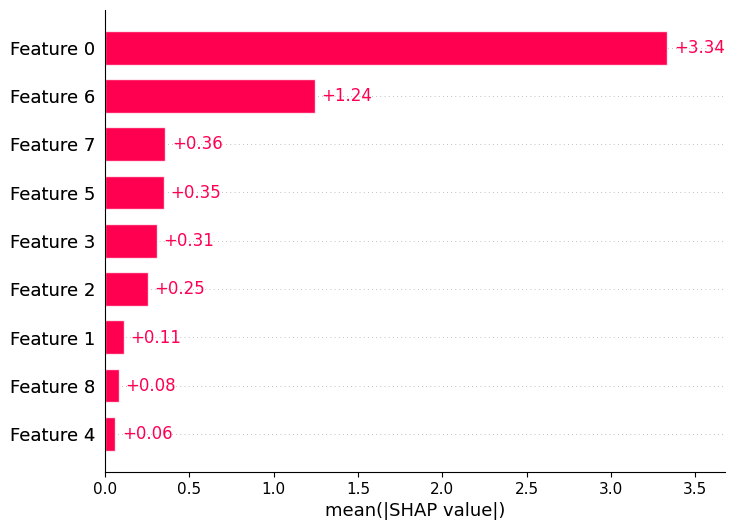

In [55]:
shap.plots.bar(shap_values)

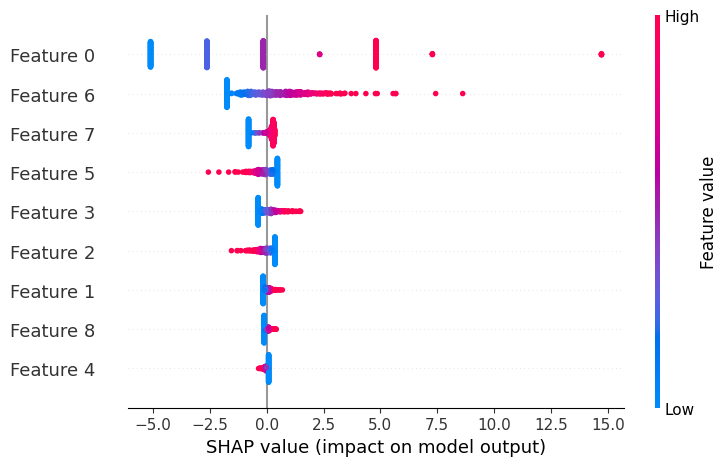

In [56]:
shap.plots.beeswarm(shap_values)

In [57]:
zone_analysis = (
    df.groupby('zone')
    .agg(
        total_work_minutes=('base_work_minutes', 'sum'),
        total_qty=('total_qty', 'sum'),
        order_count=('order_id', 'nunique'),
        avg_task_minutes=('base_work_minutes', 'mean'),
        avg_bins=('unique_bins', 'mean'),
        avg_volume=('total_volume_cm3', 'mean')
    )
    .reset_index()
)

zone_analysis['work_minutes_per_unit'] = (
    zone_analysis['total_work_minutes']
    / zone_analysis['total_qty']
)

zone_analysis.sort_values(
    'total_work_minutes',
    ascending=False
).head(10)

,zone,total_work_minutes,total_qty,order_count,avg_task_minutes,avg_bins,avg_volume,work_minutes_per_unit
37,combo_9,118278.166667,497966.0,1565,75.577103,98.122684,168337.952701,0.237523
29,combo_11,77499.000000,239718.0,1571,49.330999,73.230426,50923.526610,0.323292
34,combo_6,68887.583333,214549.0,1571,43.849512,64.937619,60109.765514,0.321081
12,FMCG_FOOD2,68323.166667,262358.0,1557,43.881289,59.678870,63617.255866,0.260420
36,combo_8,59161.083333,175123.0,1571,37.658233,56.737747,149750.133693,0.337826
25,SPICES&DAL,49457.916667,180827.0,1559,31.724129,44.116742,46678.398188,0.273510
11,FMCG_FOOD1,49368.416667,180683.0,1558,31.687045,44.045571,55323.869541,0.273232
1,BISC_BAK,42547.083333,181627.0,1557,27.326322,35.210662,43096.478163,0.234255
33,combo_5,40729.916667,184241.0,1556,26.176039,32.617609,40997.039680,0.221069
26,STAPLES,37743.916667,180581.0,1544,24.445542,29.398316,38918.273608,0.209014


In [58]:
bottleneck_zone = (
    simulation_df
    .loc[
        simulation_df.groupby(
            ['order_date', 'order_id']
        )['completion_time'].idxmax()
    ][['order_date', 'order_id', 'zone']]
    .rename(columns={'zone': 'bottleneck_zone'})
)

print(bottleneck_zone.shape)
display(bottleneck_zone.head())

(1924, 3)


,order_date,order_id,bottleneck_zone
1506,2025-11-08,BLR_127930,SPICES&DAL
1531,2025-11-08,BLR_127931,combo_9
740,2025-11-08,BLR_127932,combo_2
349,2025-11-08,BLR_127933,combo_9
364,2025-11-08,BLR_127935,combo_9


In [59]:
bottleneck_risk = bottleneck_zone.merge(
    order_completion[
        ['order_date', 'order_id', 'high_risk']
    ],
    on=['order_date', 'order_id'],
    how='left'
)

bottleneck_summary = (
    bottleneck_risk
    .groupby('bottleneck_zone')
    .agg(
        times_bottleneck=('order_id', 'count'),
        times_caused_high_risk=('high_risk', 'sum')
    )
)

bottleneck_summary['high_risk_causation_rate'] = (
    bottleneck_summary['times_caused_high_risk']
    / bottleneck_summary['times_bottleneck']
)

bottleneck_summary = bottleneck_summary.sort_values(
    'high_risk_causation_rate',
    ascending=False
)

display(bottleneck_summary.head(15))

,times_bottleneck,times_caused_high_risk,high_risk_causation_rate
bottleneck_zone,,,
combo_4,5,2,0.400000
DIAPERS,3,1,0.333333
FMCG_FOOD1,16,5,0.312500
CD_CICO,16,4,0.250000
BISC_BAK,43,7,0.162791
FMCG_FOOD2,83,13,0.156627
FRAGILE_FD,26,4,0.153846
combo_6,72,10,0.138889
combo_9,978,126,0.128834


In [60]:
zone_priority = (
    zone_analysis
    .merge(
        bottleneck_summary.reset_index(),
        left_on='zone',
        right_on='bottleneck_zone',
        how='left'
    )
)

zone_priority['bottleneck_share'] = (
    zone_priority['times_bottleneck']
    / zone_priority['times_bottleneck'].sum()
)

zone_priority['high_risk_share'] = (
    zone_priority['times_caused_high_risk']
    / zone_priority['times_caused_high_risk'].sum()
)

zone_priority = zone_priority.sort_values(
    'high_risk_share',
    ascending=False
)

display(
    zone_priority[
        [
            'zone',
            'total_work_minutes',
            'work_minutes_per_unit',
            'times_bottleneck',
            'bottleneck_share',
            'times_caused_high_risk',
            'high_risk_share',
            'high_risk_causation_rate'
        ]
    ].head(15)
)

,zone,total_work_minutes,work_minutes_per_unit,times_bottleneck,bottleneck_share,times_caused_high_risk,high_risk_share,high_risk_causation_rate
37,combo_9,118278.166667,0.237523,978.0,0.508316,126.0,0.608696,0.128834
29,combo_11,77499.000000,0.323292,170.0,0.088358,19.0,0.091787,0.111765
12,FMCG_FOOD2,68323.166667,0.260420,83.0,0.043139,13.0,0.062802,0.156627
34,combo_6,68887.583333,0.321081,72.0,0.037422,10.0,0.048309,0.138889
1,BISC_BAK,42547.083333,0.234255,43.0,0.022349,7.0,0.033816,0.162791
30,combo_2,23287.833333,0.188966,305.0,0.158524,7.0,0.033816,0.022951
36,combo_8,59161.083333,0.337826,109.0,0.056653,6.0,0.028986,0.055046
11,FMCG_FOOD1,49368.416667,0.273232,16.0,0.008316,5.0,0.024155,0.312500
2,CD_CICO,29139.833333,0.118326,16.0,0.008316,4.0,0.019324,0.250000
13,FRAGILE_FD,31328.000000,0.303002,26.0,0.013514,4.0,0.019324,0.153846


In [61]:
pareto = zone_priority.copy()

pareto = pareto.sort_values(
    'total_work_minutes',
    ascending=False
)

pareto['cumulative_work_share'] = (
    pareto['total_work_minutes'].cumsum()
    / pareto['total_work_minutes'].sum()
)

pareto['cumulative_high_risk_share'] = (
    pareto['high_risk_share'].cumsum()
)

display(
    pareto[
        [
            'zone',
            'total_work_minutes',
            'high_risk_share',
            'cumulative_work_share',
            'cumulative_high_risk_share'
        ]
    ]
)

,zone,total_work_minutes,high_risk_share,cumulative_work_share,cumulative_high_risk_share
37,combo_9,118278.166667,0.608696,0.124046,0.608696
29,combo_11,77499.000000,0.091787,0.205324,0.700483
34,combo_6,68887.583333,0.048309,0.277571,0.748792
12,FMCG_FOOD2,68323.166667,0.062802,0.349225,0.811594
36,combo_8,59161.083333,0.028986,0.411271,0.840580
25,SPICES&DAL,49457.916667,0.000000,0.463141,0.840580
11,FMCG_FOOD1,49368.416667,0.024155,0.514917,0.864734
1,BISC_BAK,42547.083333,0.033816,0.559539,0.898551
33,combo_5,40729.916667,0.000000,0.602255,0.898551
26,STAPLES,37743.916667,0.000000,0.641839,0.898551


In [62]:
pareto['high_risk_share'] = pareto['high_risk_share'].fillna(0)
pareto['cumulative_high_risk_share'] = (
    pareto['high_risk_share'].cumsum()
)

In [63]:
display(
    pareto[
        [
            'zone',
            'total_work_minutes',
            'high_risk_share',
            'cumulative_work_share',
            'cumulative_high_risk_share'
        ]
    ].head(10)
)

,zone,total_work_minutes,high_risk_share,cumulative_work_share,cumulative_high_risk_share
37,combo_9,118278.166667,0.608696,0.124046,0.608696
29,combo_11,77499.000000,0.091787,0.205324,0.700483
34,combo_6,68887.583333,0.048309,0.277571,0.748792
12,FMCG_FOOD2,68323.166667,0.062802,0.349225,0.811594
36,combo_8,59161.083333,0.028986,0.411271,0.840580
25,SPICES&DAL,49457.916667,0.000000,0.463141,0.840580
11,FMCG_FOOD1,49368.416667,0.024155,0.514917,0.864734
1,BISC_BAK,42547.083333,0.033816,0.559539,0.898551
33,combo_5,40729.916667,0.000000,0.602255,0.898551
26,STAPLES,37743.916667,0.000000,0.641839,0.898551


In [64]:
zone_recommendation = zone_priority.copy()

def classify_zone(row):
    if row['high_risk_share'] >= 0.05:
        return 'Priority 1 - High Risk Impact'
    elif row['high_risk_share'] >= 0.02:
        return 'Priority 2 - Investigate'
    elif row['work_minutes_per_unit'] >= zone_priority['work_minutes_per_unit'].quantile(0.75):
        return 'Efficiency Opportunity'
    else:
        return 'Monitor'

zone_recommendation['action_category'] = (
    zone_recommendation.apply(classify_zone, axis=1)
)

display(
    zone_recommendation[
        [
            'zone',
            'total_work_minutes',
            'work_minutes_per_unit',
            'times_bottleneck',
            'times_caused_high_risk',
            'high_risk_share',
            'high_risk_causation_rate',
            'action_category'
        ]
    ].sort_values(
        'high_risk_share',
        ascending=False
    ).head(15)
)

,zone,total_work_minutes,work_minutes_per_unit,times_bottleneck,times_caused_high_risk,high_risk_share,high_risk_causation_rate,action_category
37,combo_9,118278.166667,0.237523,978.0,126.0,0.608696,0.128834,Priority 1 - High Risk Impact
29,combo_11,77499.000000,0.323292,170.0,19.0,0.091787,0.111765,Priority 1 - High Risk Impact
12,FMCG_FOOD2,68323.166667,0.260420,83.0,13.0,0.062802,0.156627,Priority 1 - High Risk Impact
34,combo_6,68887.583333,0.321081,72.0,10.0,0.048309,0.138889,Priority 2 - Investigate
1,BISC_BAK,42547.083333,0.234255,43.0,7.0,0.033816,0.162791,Priority 2 - Investigate
30,combo_2,23287.833333,0.188966,305.0,7.0,0.033816,0.022951,Priority 2 - Investigate
36,combo_8,59161.083333,0.337826,109.0,6.0,0.028986,0.055046,Priority 2 - Investigate
11,FMCG_FOOD1,49368.416667,0.273232,16.0,5.0,0.024155,0.312500,Priority 2 - Investigate
2,CD_CICO,29139.833333,0.118326,16.0,4.0,0.019324,0.250000,Monitor
13,FRAGILE_FD,31328.000000,0.303002,26.0,4.0,0.019324,0.153846,Monitor


In [65]:
# Dashboard exports

order_completion.to_csv(
    '/content/drive/MyDrive/Colab Notebooks/Warehouse/dashboard_order_completion.csv',
    index=False
)

zone_recommendation.to_csv(
    '/content/drive/MyDrive/Colab Notebooks/Warehouse/dashboard_zone_recommendation.csv',
    index=False
)

simulation_df.to_csv(
    '/content/drive/MyDrive/Colab Notebooks/Warehouse/dashboard_simulation.csv',
    index=False
)

# Generate SHAP summary directly from the SHAP object
shap_summary = pd.DataFrame({
    'feature': X_test.columns,
    'mean_abs_shap': np.abs(shap_values.values).mean(axis=0)
}).sort_values(
    'mean_abs_shap',
    ascending=False
)

shap_summary.to_csv(
    '/content/drive/MyDrive/Colab Notebooks/Warehouse/dashboard_shap_summary.csv',
    index=False
)

print("All dashboard files exported successfully.")
display(shap_summary)

All dashboard files exported successfully.


,feature,mean_abs_shap
0,priority_num,3.336042
6,total_volume_cm3,1.243441
7,number_of_zones,0.357205
5,total_weight_kg,0.347666
3,total_qty,0.305843
2,unique_skus,0.253845
1,sku_lines,0.111087
8,total_base_work_seconds,0.083019
4,unique_bins,0.060956


In [66]:
import os

files = [
    'dashboard_order_completion.csv',
    'dashboard_zone_recommendation.csv',
    'dashboard_simulation.csv',
    'dashboard_shap_summary.csv'
]

for f in files:
    path = f'/content/drive/MyDrive/Colab Notebooks/Warehouse/{f}'
    print(f, "→", os.path.getsize(path) / 1024, "KB")

dashboard_order_completion.csv → 135.912109375 KB
dashboard_zone_recommendation.csv → 6.51953125 KB
dashboard_simulation.csv → 4765.615234375 KB
dashboard_shap_summary.csv → 0.318359375 KB


In [67]:
df.head()

,order_id,zone,order_date,store_id,priority_num,sku_lines,unique_skus,total_qty,unique_bins,total_weight_kg,total_volume_cm3,zone_complexity_tier,travel_seconds,pickup_seconds,base_work_seconds,base_work_minutes,simulated_work_seconds
0,BLR_120033,BISC_BAK,2025-11-14,401004.0,5,1,1,2.0,1,0.375,1805.000,4,30,10.0,40.0,0.666667,42.384228
1,BLR_120033,CHOCOLATES,2025-11-14,401004.0,5,2,2,4.0,2,0.287,1351.286,4,60,20.0,80.0,1.333333,78.672663
2,BLR_120033,DIAPERS,2025-11-14,401004.0,5,1,1,1.0,1,0.810,8615.520,3,30,5.0,35.0,0.583333,37.720292
3,BLR_120033,DP+DB,2025-11-14,401004.0,5,4,4,4.0,4,8.148,11185.250,3,120,20.0,140.0,2.333333,165.586902
4,BLR_120033,FMCG_FOOD1,2025-11-14,401004.0,5,1,1,2.0,1,0.200,2000.000,6,30,10.0,40.0,0.666667,38.876064


In [70]:
# ============================================================
# Already run earlier in your notebook (cells 48-50) — shown here
# for reference, not to re-run:
#   X_train, X_test, y_train, y_test = train_test_split(X, y, ...)
#   scaler = StandardScaler(); X_train_scaled = scaler.fit_transform(X_train)
#   log_model = LogisticRegression(class_weight='balanced', ...).fit(X_train_scaled, y_train)
#   y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]
# ============================================================

from sklearn.metrics import roc_auc_score

# 1. Predict probability for EVERY order — dashboard needs the full
#    1,924-order population, not just the 385-order test split.
#    Use X.columns (the exact feature set log_model was fit on) to
#    build X_full — never re-derive it with .drop(), which silently
#    breaks if order_features gains new columns later.
X_full = order_features[X.columns]
X_full_scaled = scaler.transform(X_full)   # same fitted scaler — never refit here
order_features['predicted_high_risk_probability'] = log_model.predict_proba(X_full_scaled)[:, 1]

# 2. ROC-AUC — test set only, already computed correctly in cell 50,
#    just confirming here so it's next to the CSV export
roc_auc = roc_auc_score(y_test, y_prob_log)
print("ROC-AUC (logistic regression, test set only):", round(roc_auc, 3))

# 3. Bring in completion time from order_completion (not in order_features)
risk_df = order_features.merge(
    order_completion[['order_date', 'order_id', 'order_completion_minutes']],
    on=['order_date', 'order_id'], how='left'
)

# 4. Trim to the 7 columns the dashboard charts need
risk_df = risk_df[['order_id', 'priority_num', 'predicted_high_risk_probability',
                    'order_completion_minutes', 'total_volume_cm3',
                    'total_weight_kg', 'high_risk']].copy()

# 5. Bucket columns for the three bucketed charts
risk_df['probability_bin'] = pd.cut(risk_df['predicted_high_risk_probability'],
    bins=[0,.1,.2,.3,.4,.5,.6,.7,.8,.9,1.0],
    labels=['0.0-0.1','0.1-0.2','0.2-0.3','0.3-0.4','0.4-0.5',
            '0.5-0.6','0.6-0.7','0.7-0.8','0.8-0.9','0.9-1.0'], include_lowest=True)

risk_df['volume_bucket'] = pd.cut(risk_df['total_volume_cm3'],
    bins=[-float('inf'),50000,100000,200000,500000,float('inf')],
    labels=['<=50k','50k-100k','100k-200k','200k-500k','>500k'])

risk_df['weight_bucket'] = pd.cut(risk_df['total_weight_kg'],
    bins=[-float('inf'),5,10,20,50,float('inf')],
    labels=['<=5','5-10','10-20','20-50','>50'])

bin_order_map = {'0.0-0.1':0,'0.1-0.2':1,'0.2-0.3':2,'0.3-0.4':3,'0.4-0.5':4,
                  '0.5-0.6':5,'0.6-0.7':6,'0.7-0.8':7,'0.8-0.9':8,'0.9-1.0':9}
risk_df['probability_bin_order'] = risk_df['probability_bin'].map(bin_order_map)

print(risk_df.shape)
risk_df.head()

ROC-AUC (logistic regression, test set only): 0.979
(1924, 11)


,order_id,priority_num,predicted_high_risk_probability,order_completion_minutes,total_volume_cm3,total_weight_kg,high_risk,probability_bin,volume_bucket,weight_bucket,probability_bin_order
0,BLR_127930,5,0.355255,516.460516,140348.561568,24.440350,False,0.3-0.4,100k-200k,20-50,3
1,BLR_127931,5,0.574463,543.186435,456486.714708,164.997302,False,0.5-0.6,200k-500k,>50,5
2,BLR_127932,2,0.000154,221.092753,115.500000,0.001000,False,0.0-0.1,<=50k,<=5,0
3,BLR_127933,1,0.000045,138.011361,265176.465086,34.275320,False,0.0-0.1,200k-500k,20-50,0
4,BLR_127935,1,0.000057,140.732117,365160.304714,65.945480,False,0.0-0.1,200k-500k,>50,0


In [72]:
risk_df.to_csv('/content/drive/MyDrive/Colab Notebooks/Warehouse/dashboard_order_risk.csv', index=False)